In [1]:

import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = 10*loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):

    logm1lim = [5.9, 6.2]
    logm2lim = [1.3,1.6]
    alim = [0.6, 0.8]
    p0lim= [10.0, 13.0]
    e0lim = [0.3, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.97163342241979
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_1mth_faceon/sampler_state.pkl')

In [3]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [4]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.33952501, 0.52470499, 0.65816498, 0.52265501, 0.53657502],
        [0.3395297 , 0.52470322, 0.65816693, 0.52265988, 0.53657848],
        [0.33951189, 0.52471823, 0.65815062, 0.52266441, 0.53658968],
        ...,
        [0.41940227, 0.33941277, 1.18391927, 0.29035911, 0.66868909],
        [0.23416821, 0.46400245, 0.25144527, 0.66567842, 0.6152082 ],
        [0.36583691, 0.64639047, 0.54356367, 0.54860943, 0.44979178]],
       shape=(100000, 5))]

In [5]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([20.58510456, 20.61694794, 20.59682587, ...,        -inf,
        47.50356827, 42.73256228], shape=(100000,))]

In [6]:
maxld_pt = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt

array([[ 6.02495386,  1.46072375,  0.78132966, 11.19827629,  0.40443896]])

In [7]:
param_true

[np.float64(6.0), np.float64(1.4771212547196624), 0.7, 11.7, 0.4]

In [8]:
param_ranges = [(5.9,6.2),
                (1.3,1.6),
                (0.6,0.8),
                (10.0,13.0),
                (0.3,0.5)
                ]
param_ranges

[(5.9, 6.2), (1.3, 1.6), (0.6, 0.8), (10.0, 13.0), (0.3, 0.5)]

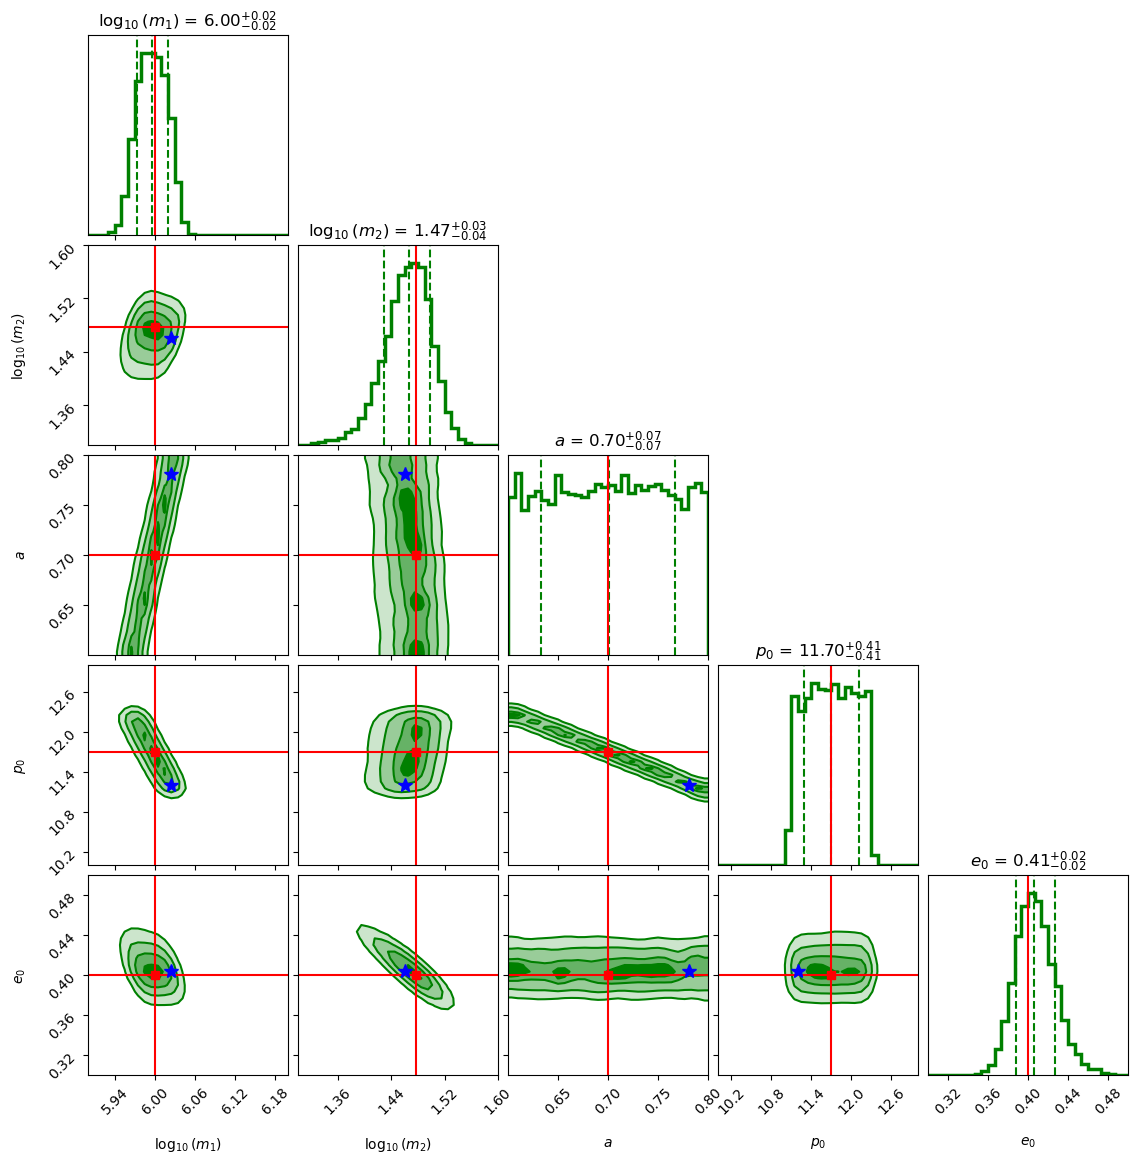

In [9]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

# corner.overplot_points(fig, proc2_maxld_pt.reshape(1, -1), 
#                        color='orange', marker='*', ms=10,
#                        reverse=False)



In [11]:
maxld_pt

array([[ 6.02495386,  1.46072375,  0.78132966, 11.19827629,  0.40443896]])

In [12]:
h_pt1 = waveform_gen_comb(10**6.02495386,10**1.46072375,  0.78132966, 11.19827629,  0.40443896, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt,
    T=T
)



In [13]:
gwf.overlap(gwf.freq_wave(data), gwf.freq_wave(h_pt1))

array(0.99724804)

In [10]:
p0_samples = samples.T[3]

In [11]:
print(f"Min p0 sample: {p0_samples.min()}")  
print(f"Max p0 sample: {p0_samples.max()}")  

Min p0 sample: 9.851873330453767
Max p0 sample: 13.474666591709187


In [12]:
all_pts = prior_transform(proc_pt[0])  
all_logden = logden_list[0]
finite_mask = np.isfinite(all_logden)

a_vals = all_pts[:, 2]
extreme_a_mask = (a_vals < 0.65) | (a_vals > 0.75)  
logden_threshold = np.percentile(all_logden[finite_mask], 99)
high_logden_mask = all_logden > logden_threshold
combined_mask = finite_mask & extreme_a_mask & high_logden_mask
filtered_pts = all_pts[combined_mask]
filtered_logden = all_logden[combined_mask]

best_idx = np.argmax(filtered_logden)
test_point = filtered_pts[best_idx]
print(f"\nSelected point: {test_point}")
print(f"Logden: {filtered_logden[best_idx]:.4f}")



Selected point: [ 6.02495386  1.46072375  0.78132966 11.19827629  0.40443896]
Logden: 59.5391


In [13]:
result = log_density(test_point.reshape(1, -1))
print(f"log_density result: {result[0]:.4f}")
print(f"Stored log density: {filtered_logden[best_idx]:.4f}")


log_density result: 59.5391
Stored log density: 59.5391


In [14]:
log_density([test_point])

array([59.53912518])

In [15]:
log_density([param_true])

array([59.48043158])

In [18]:
logm1, logm2, a_val, p0_val, e0_val = test_point
m1_val = 10**logm1
m2_val = 10**logm2

h_test = waveform_gen_comb(m1_val, m2_val, a_val, p0_val, e0_val,
                       xI0, dist, qS, phiS, qK, phiK,
                       Phi_phi0, Phi_theta0, Phi_r0,
                       dt=dt, T=T)

test_snr = gwf.Xstat(data,h_test)
true_snr = gwf.Xstat(data,data)

print(f"Optimal SNR at test point: {test_snr}")
print(f"Optimal SNR at true point: {true_snr}")

Optimal SNR at test point: 5.9639519424044325
Optimal SNR at true point: 5.97163342241979


In [19]:
gwf.rhostat_timemax(h_test)

array(6.09399372)

In [20]:
gwf_2yr = GWfuncs.GravWaveAnalysis(2, dt)


In [22]:


h_test_2yr = waveform_gen_comb(m1_val, m2_val, a_val, p0_val, e0_val,
                       xI0, dist, qS, phiS, qK, phiK,
                       Phi_phi0, Phi_theta0, Phi_r0,
                       dt=dt, T=2)

h_true_2yr = waveform_gen_comb(m1, m2, a, p0, e0,
                       xI0, dist, qS, phiS, qK, phiK,
                       Phi_phi0, Phi_theta0, Phi_r0,
                       dt=dt, T=2)

snr_test_2yr = gwf_2yr.rhostat(h_test_2yr)
snr_true_2yr = gwf_2yr.rhostat(h_true_2yr)
print(f" SNR at test point (2yr): {snr_test_2yr}")
print(f" SNR at true point (2yr): {snr_true_2yr}")

 SNR at test point (2yr): 87.840345851274
 SNR at true point (2yr): 96.98740603613615


In [27]:
test_snr = gwf_2yr.Xstat(h_true_2yr,h_test_2yr)
true_snr = gwf_2yr.Xstat(h_true_2yr,h_true_2yr)

print(f"Optimal SNR at test point: {test_snr}")
print(f"Optimal SNR at true point: {true_snr}")

Optimal SNR at test point: 0.6176966306096886
Optimal SNR at true point: 96.98740603613615


In [28]:
gwf_3mth = GWfuncs.GravWaveAnalysis(3/12, dt)


In [29]:


h_test_3mth = waveform_gen_comb(m1_val, m2_val, a_val, p0_val, e0_val,
                       xI0, dist, qS, phiS, qK, phiK,
                       Phi_phi0, Phi_theta0, Phi_r0,
                       dt=dt, T=3/12)

h_true_3mth = waveform_gen_comb(m1, m2, a, p0, e0,
                       xI0, dist, qS, phiS, qK, phiK,
                       Phi_phi0, Phi_theta0, Phi_r0,
                       dt=dt, T=3/12)

test_snr = gwf_3mth.Xstat(h_true_3mth,h_test_3mth)
true_snr = gwf_3mth.Xstat(h_true_3mth,h_true_3mth)

print(f"Optimal SNR at test point: {test_snr}")
print(f"Optimal SNR at true point: {true_snr}")

Optimal SNR at test point: 4.594864924505053
Optimal SNR at true point: 10.714024617672264


In [23]:
gwf_2yr.rhostat_timemax(h_test_2yr)


array(87.84034585)

In [24]:
gwf_2yr.rhostat_timemax(h_true_2yr)

array(96.98740604)

p0=8.00  loglike=0.003
p0=8.60  loglike=0.002
p0=9.20  loglike=0.009
p0=9.80  loglike=0.005
p0=10.40  loglike=0.038
p0=11.00  loglike=0.002
p0=11.70  loglike=5.948
p0=12.00  loglike=0.004
p0=12.80  loglike=0.105
p0=13.60  loglike=0.056
p0=14.40  loglike=0.026
p0=15.20  loglike=0.140
p0=16.00  loglike=0.291


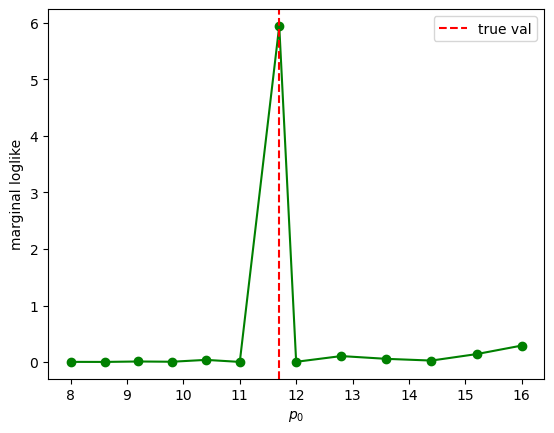

In [25]:
p0_grid = np.concatenate([
    np.linspace(8.0, 11.0, 6),  
    np.array([11.7]),            
    np.linspace(12.0, 16.0, 6),  
])

loglikes = []
for p0_test in p0_grid:
    ll = loglike_obj(np.array([m1, m2, a, p0_test, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
    loglikes.append(ll)
    print(f"p0={p0_test:.2f}  loglike={ll:.3f}")

loglikes = np.array(loglikes)

plt.figure()
plt.plot(p0_grid, loglikes, 'o-', color='green')
plt.axvline(11.7, color='red', linestyle='--', label='true val')
plt.xlabel('$p_0$')
plt.ylabel('marginal loglike')
plt.legend()
plt.show()